In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Ensure that before running the whole script that you install onnx, onnxscript and upload the dataset

In [ ]:
# model.py
import torch
import torch.nn as nn

class MLPFaultPredictor(nn.Module):
    """
    Standard Multi-Layer Perceptron baseline.
    Flattens the sequential input window into a single feature vector.
    """
    def __init__(self, num_features, num_classes, seq_len=10):
        super(MLPFaultPredictor, self).__init__()
        self.flatten = nn.Flatten()
        # Input size is 10 time steps * 18 features = 180 inputs
        self.fc1 = nn.Linear(seq_len * num_features, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.out(x)


class CNN1DFaultPredictor(nn.Module):
    """
    One-Dimensional Convolutional Neural Network.
    Highly accelerated on Cortex-M4 via ARM CMSIS-NN kernels.
    """
    def __init__(self, num_features, num_classes):
        super(CNN1DFaultPredictor, self).__init__()
        # Conv1d expects input shape: (Batch, Channels, Length)
        # We treat our 18 features as Channels and sequence length (10) as Length.
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)  # Downsamples time length from 10 to 5
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        # Output spatial dim is 5. Total linear input features = 16 channels * 5 = 80
        self.fc = nn.Linear(16 * 5, num_classes)

    def forward(self, x):
        # Permute input from (Batch, Seq_len, Features) to (Batch, Features, Seq_len)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.flatten(x)
        return self.fc(x)


class LSTMFaultPredictor(nn.Module):
    """
    Long Short-Term Memory Network.
    Enforces stateless execution to meet X-CUBE-AI ONNX export constraints.
    """
    def __init__(self, num_features, num_classes, hidden_size=16):
        super(LSTMFaultPredictor, self).__init__()
        # batch_first=True is mandatory for robust ONNX/TFLite export
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # We do NOT pass hidden or cell state tuples (h0, c0) in the forward path.
        # This forces the network to execute in stateless mode, preventing compilation errors in X-CUBE-AI.
        out, (hn, cn) = self.lstm(x)
        # Extract only the last sequence timestep's hidden state (Batch, Hidden_size)
        return self.fc(out[:, -1, :])


class GRUFaultPredictor(nn.Module):
    """
    Gated Recurrent Unit Network.
    More parameter-efficient than LSTM while capturing temporal dynamics.
    """
    def __init__(self, num_features, num_classes, hidden_size=16):
        super(GRUFaultPredictor, self).__init__()
        self.gru = nn.GRU(input_size=num_features, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, hn = self.gru(x)
        return self.fc(out[:, -1, :])


class HybridFaultPredictor(nn.Module):
    """
    CNN-GRU Hybrid Network (Corresponds to your main predict.py pipeline).
    Extracts high-level spatial-temporal features before feeding sequence blocks to the GRU.
    """
    def __init__(self, num_features, num_classes, hidden_size=16):
        super(HybridFaultPredictor, self).__init__()
        # Conv stage
        self.conv = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        # Recurrent stage
        self.gru = nn.GRU(input_size=16, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Transpose input: (Batch, Seq_len=10, Features=18) -> (Batch, Features=18, Seq_len=10)
        x_conv = x.permute(0, 2, 1)
        x_conv = self.relu(self.conv(x_conv))
        # Transpose back for GRU: (Batch, Seq_len=10, Channels=16)
        x_seq = x_conv.permute(0, 2, 1)
        out, hn = self.gru(x_seq)
        return self.fc(out[:, -1, :])


class StackedAutoencoder(nn.Module):
    """
    Stacked Autoencoder for unsupervised anomaly detection.
    Optimized for reconstruction error thresholding under tight SRAM.
    """
    def __init__(self, num_features, seq_len=10):
        super(StackedAutoencoder, self).__init__()
        self.input_dim = num_features * seq_len

        # Dense bottleneck compression
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        # Symmetric expansion
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, self.input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        encoded = self.encoder(x_flat)
        decoded = self.decoder(encoded)
        # Reshape reconstructed flat vector back to original sequence dims (Batch, Seq_len, Features)
        return decoded.view(batch_size, x.size(1), x.size(2))


class ELMPyTorch(nn.Module):
    """
    Extreme Learning Machine (ELM) PyTorch wrapper for standard backprop benchmarking.
    The input projection is randomized and statically frozen; only the output layer trains.
    """
    def __init__(self, num_features, num_classes, hidden_size=64, seq_len=10):
        super(ELMPyTorch, self).__init__()
        self.input_dim = num_features * seq_len

        # Create non-trainable random input weights and biases (mimicking analytical ELM)
        self.input_weights = nn.Parameter(torch.randn(self.input_dim, hidden_size), requires_grad=False)
        self.biases = nn.Parameter(torch.randn(hidden_size), requires_grad=False)
        self.relu = nn.ReLU()
        # Trainable output layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        # Static random projection
        h = torch.matmul(x_flat, self.input_weights) + self.biases
        h = self.relu(h)
        return self.fc(h)

In [ ]:
import torch
import joblib
import onnx

def export_pytorch_to_onnx(model, model_name, input_shape, device):
    """
    Exports PyTorch models to ONNX format for STM32 X-CUBE-AI.
    """
    model.eval()
    # Create a dummy input tensor that perfectly matches your grid data shape
    dummy_input = torch.randn(input_shape).to(device)

    onnx_filename = f"{model_name.replace(' ', '_')}.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=11,          # Opset 11 is highly compatible with X-CUBE-AI
        do_constant_folding=True,  # Optimizes the graph for edge deployment
        input_names=['pmu_input'],
        output_names=['fault_prediction']
    )
    print(f"📦 Exported {model_name} to {onnx_filename}")

def export_scaler_to_c_header(scaler, filename="grid_scaler.h"):
    """
    Dumps StandardScaler mean and scale values to a C header file.
    The STM32 needs this to normalize raw sensor readings before inferencing.
    """
    with open(filename, 'w') as f:
        f.write("#ifndef GRID_SCALER_H\n#define GRID_SCALER_H\n\n")
        f.write(f"// Standard Scaler Parameters for {len(scaler.mean_)} features\n")

        # Write Means
        f.write("const float SCALER_MEAN[] = {\n    ")
        f.write(", ".join([f"{val}f" for val in scaler.mean_]))
        f.write("\n};\n\n")

        # Write Scales (Standard Deviations)
        f.write("const float SCALER_SCALE[] = {\n    ")
        f.write(", ".join([f"{val}f" for val in scaler.scale_]))
        f.write("\n};\n\n")

        f.write("#endif // GRID_SCALER_H\n")
    print(f"📦 Exported Scaler parameters to {filename}")

def export_elm_to_c_header(W_in, b, Beta, filename="elm_weights.h"):
    """
    Dumps Extreme Learning Machine weights into C arrays for direct
    CMSIS-DSP matrix multiplication on the MCU.
    """
    def array_to_c_string(arr, name):
        flat_arr = arr.flatten()
        c_str = f"const float {name}[{len(flat_arr)}] = {{\n    "
        c_str += ", ".join([f"{val}f" for val in flat_arr])
        c_str += "\n};\n"
        return c_str

    with open(filename, 'w') as f:
        f.write("#ifndef ELM_WEIGHTS_H\n#define ELM_WEIGHTS_H\n\n")
        f.write("// ELM Network Weights\n")
        f.write(array_to_c_string(W_in, "ELM_W_IN"))
        f.write(array_to_c_string(b, "ELM_BIAS"))
        f.write(array_to_c_string(Beta, "ELM_BETA"))
        f.write("\n#endif // ELM_WEIGHTS_H\n")
    print(f"📦 Exported ELM weights to {filename}")

def export_recurrent_model_to_onnx(model, model_name, seq_len, num_features,device):
    """
    Strictly forces static single-sample shapes for GRU/LSTM models
    to completely eliminate runtime ONNX Transpose nodes.
    """
    model.eval()

    # CRITICAL: Batch size MUST be hardcoded to 1 for microcontrollers
    # Shape layout: (Batch=1, Sequence_Length=Window_Size, Features=18)
    dummy_input = torch.randn(1, seq_len, num_features).to(device)

    onnx_filename = f"{model_name.replace(' ', '_')}recurrent_new.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=13,            # Opset 13 handles recurrent flatten layers cleanly
        do_constant_folding=True,
        input_names=['grid_sensor_input'],
        output_names=['fault_class_output'],
        dynamic_axes=None            # 🚨 DO NOT USE DYNAMIC AXES. Keep it totally static.
    )
    print(f"📦 Static recurrent model exported to: {onnx_filename}")

In [ ]:
import os
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.ensemble import RandomForestClassifier

# Set random seeds for absolute experimental reproducibility
torch.manual_seed(42)
np.random.seed(42)

def export_pytorch_to_onnx(model, model_name, input_shape, device):
    """
    Exports PyTorch models to ONNX format for STM32 X-CUBE-AI.
    Updated opset_version to 18 for compatibility.
    """
    model.eval()
    # Create a dummy input tensor that perfectly matches your grid data shape
    dummy_input = torch.randn(input_shape).to(device)

    onnx_filename = f"{model_name.replace(' ', '_')}.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=18,          # Changed from 13 to 18 for compatibility
        do_constant_folding=True,  # Optimizes the graph for edge deployment
        input_names=['pmu_input'],
        output_names=['fault_prediction']
    )
    print(f"📦 Exported {model_name} to {onnx_filename}")

# =====================================================================
# 1. Tabular and Single-Step Recurrent Model Definitions
# =====================================================================

class MLPFaultPredictor(nn.Module):
    """
    Standard Multi-Layer Perceptron optimized for tabular grid feature maps.
    """
    def __init__(self, num_features, num_classes):
        super(MLPFaultPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # Flatten sequence dimension if 3D: (Batch, 1, 18) -> (Batch, 18)
        if len(x.shape) == 3:
            x = x.squeeze(1)
        return self.network(x)

class CNN1DFaultPredictor(nn.Module):
    """
    One-Dimensional Convolutional Neural Network.
    Processes features as channels for spatial feature extraction.
    """
    def __init__(self, num_features, num_classes):
        super(CNN1DFaultPredictor, self).__init__()
        # Input shape: (Batch, Features, 1)
        self.conv = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten() # Added missing flatten layer
        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        if len(x.shape) == 3:
            # Shape: (Batch, 1, Features) -> (Batch, Features, 1)
            x = x.permute(0, 2, 1)
        else:
            # Shape: (Batch, Features) -> (Batch, Features, 1)
            x = x.unsqueeze(2)
        x = self.relu(self.conv(x))
        x = self.flatten(x)
        return self.fc(x)

import torch
import torch.nn as nn

class EmbeddedStatelessLSTM(nn.Module):
    def __init__(self, input_size=18, hidden_size=32, num_classes=5):
        super(EmbeddedStatelessLSTM, self).__init__()
        self.hidden_size = hidden_size

        # 1. Use LSTMCell instead of standard nn.LSTM
        self.lstm_cell = nn.LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Expected input shape: (Batch, Sequence_Length, Features)
        # If input is 2D (batch_size, num_features), unsqueeze to (batch_size, 1, num_features)
        if len(x.shape) == 2:
            x = x.unsqueeze(1) # Add a sequence length dimension of 1

        batch_size, seq_len, _ = x.size()

        # 2. Initialize BOTH the hidden state (hx) and cell state (cx)
        hx = torch.zeros(batch_size, self.hidden_size, device=x.device)
        cx = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # 3. Manually unroll the time-series loop step-by-step
        for t in range(seq_len):
            hx, cx = self.lstm_cell(x[:, t, :], (hx, cx))

        # Final classification using the last hidden state
        out = self.fc(hx)
        return out

import torch
import torch.nn as nn

class EmbeddedStatelessGRU(nn.Module):
    def __init__(self, input_size=18, hidden_size=32, num_classes=5):
        super(EmbeddedStatelessGRU, self).__init__()
        self.hidden_size = hidden_size
        # Use GRUCell instead of nn.GRU to avoid monolithic ONNX recurrent blocks
        self.gru_cell = nn.GRUCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape expected: (Batch, Sequence_Length, Features)
        # If input is 2D (batch_size, num_features), unsqueeze to (batch_size, 1, num_features)
        if len(x.shape) == 2:
            x = x.unsqueeze(1) # Add a sequence length dimension of 1

        batch_size, seq_len, _ = x.size()

        # Initialize hidden state directly on the target execution device
        hx = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # Step through the sequence manually.
        # This unrolls the network into basic, ultra-compatible linear layers.
        for t in range(seq_len):
            hx = self.gru_cell(x[:, t, :], hx)

        out = self.fc(hx)
        return out
class HybridFaultPredictor(nn.Module):
    """
    CNN-GRU Hybrid Network.
    """
    def __init__(self, num_features, num_classes, hidden_size=16):
        super(HybridFaultPredictor, self).__init__()
        self.conv = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(input_size=16, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x_conv = x.permute(0, 2, 1)
        x_conv = self.relu(self.conv(x_conv))
        x_seq = x_conv.permute(0, 2, 1)
        out, hn = self.gru(x_seq)
        return self.fc(out[:, -1, :])

class StackedAutoencoder(nn.Module):
    """
    Stacked Autoencoder for unsupervised anomaly detection.
    """
    def __init__(self, num_features):
        super(StackedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_features, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, num_features)
        )

    def forward(self, x):
        if len(x.shape) == 3:
            x = x.squeeze(1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# =====================================================================
# 2. Dataset and Preprocessing Pipelines
# =====================================================================

class TabularPowerDataset(Dataset):
    def __init__(self, X, y, apply_noise=False):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.apply_noise = apply_noise

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_val = self.X[idx]
        if self.apply_noise:
            # Inject noise to simulate sensor calibration errors
            noise = torch.randn_like(x_val) * 0.05
            x_val = x_val + noise
        return x_val, self.y[idx]

# =====================================================================
# 3. Model Training & Solving Loops
# =====================================================================

def train_pytorch_model(model, train_loader, val_loader, device, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = (val_correct / val_total) * 100.0
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model

def solve_elm_analytically(X_train, y_train, X_test, hidden_neurons=128):
    """
    Analytically solves an Extreme Learning Machine (ELM) using the
    Moore-Penrose Pseudoinverse: beta = H_dagger * T
    """
    input_dim = X_train.shape[2] if len(X_train.shape) == 3 else X_train.shape[1]
    num_classes = len(np.unique(y_train))
    T = np.eye(num_classes)[y_train]

    W_in = np.random.normal(loc=0.0, scale=0.5, size=(input_dim, hidden_neurons))
    b = np.random.normal(loc=0.0, scale=0.5, size=(hidden_neurons,))

    # Squeeze if 3D for matrix multiplication
    X_train_2d = X_train.squeeze(1) if len(X_train.shape) == 3 else X_train
    X_test_2d = X_test.squeeze(1) if len(X_test.shape) == 3 else X_test

    H_train = np.maximum(0, np.dot(X_train_2d, W_in) + b)  # ReLU
    H_dagger = np.linalg.pinv(H_train)
    Beta = np.dot(H_dagger, T)

    H_test = np.maximum(0, np.dot(X_test_2d, W_in) + b)
    predictions_logits = np.dot(H_test, Beta)
    predictions = np.argmax(predictions_logits, axis=1)
    # store the elm into a header file for inferencing
    # The function export_elm_to_c_header is in cell dDWXeDc1FKEL, ensure it's run before this.
    # For this demonstration, we'll assume it's available.
    # export_elm_to_c_header(W_in, b, Beta, "elm_deployment.h") # Commented out as export_elm_to_c_header is not defined in this cell.
    param_count = W_in.size + b.size + Beta.size
    return predictions, param_count

def train_unsupervised_autoencoder(X_train_normal, X_val_normal, device, num_features):
    """
    Trains a Stacked Autoencoder strictly on 'Normal' grid telemetry.
    Selects a 95th percentile reconstruction error threshold on validation data.
    """
    model = StackedAutoencoder(num_features=num_features).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    train_ds = TabularPowerDataset(X_train_normal, X_train_normal, apply_noise=False)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(15):
        for inputs, _ in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            reconstructed = model(inputs)
            loss = criterion(reconstructed, inputs)
            loss.backward()
            optimizer.step()

    model.eval()
    val_errors = []
    val_ds = TabularPowerDataset(X_val_normal, X_val_normal, apply_noise=False)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)
            reconstructed = model(inputs)
            error = criterion(reconstructed, inputs).item()
            val_errors.append(error)

    reconstruction_threshold = np.percentile(val_errors, 95)
    return model, reconstruction_threshold

def evaluate_autoencoder_as_classifier(model, threshold, X_test, y_test, device, normal_class_idx):
    model.eval()
    criterion = nn.MSELoss()
    predictions = []

    test_ds = TabularPowerDataset(X_test, X_test, apply_noise=False)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            reconstructed = model(inputs)
            error = criterion(reconstructed, inputs).item()
            pred = 1 if error > threshold else 0
            predictions.append(pred)

    binary_ground_truth = [0 if label == normal_class_idx else 1 for label in y_test]
    acc = accuracy_score(binary_ground_truth, predictions)
    prec, rec, f1, _ = precision_recall_fscore_support(binary_ground_truth, predictions, average='binary', zero_division=0)
    return acc, prec, rec, f1

# =====================================================================
# 4. Main Execution and Evaluation Setup
# =====================================================================

if __name__ == '__main__':
    CSV_FILE_PATH = 'NewDataSet-Comp.csv'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"=== Initializing Stratified Tabular Benchmarking Suite ===")

    if not os.path.exists(CSV_FILE_PATH):
        raise FileNotFoundError(f"CRITICAL: Dataset file not found at '{CSV_FILE_PATH}'.")

    df = pd.read_csv(CSV_FILE_PATH)
    df.fillna(df.median(numeric_only=True), inplace=True)

    # Assuming 'FaultType' is the label column based on standard EEE conventions
    X_raw = df.drop(columns=['FaultType']).values
    y_raw = df['FaultType'].values

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    NUM_CLASSES = len(le.classes_)
    normal_class_idx = list(le.classes_).index('Normal')

    print(f"Detected Target Classes ({NUM_CLASSES}): {le.classes_}")
    print(f"Normal Class Mapping Index: {normal_class_idx}")

    # --- CRITICAL FIX: Stratified, Shuffled Splitting ---
    # 70% Train, 15% Validation, 15% Test with proportional class distribution
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_raw, y_encoded, test_size=0.15, shuffle=True, stratify=y_encoded, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, shuffle=True, stratify=y_temp, random_state=42
    )

    num_features = X_train.shape[1]

    # Isolate normal data for Autoencoder training
    X_train_normal = X_train[np.where(y_train == normal_class_idx)]
    X_val_normal = X_val[np.where(y_val == normal_class_idx)]

    # Scale features strictly on training bounds to prevent leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    X_train_normal_scaled = scaler.transform(X_train_normal)
    X_val_normal_scaled = scaler.transform(X_val_normal)

    # Instantiate Tabular DataLoaders
    train_loader = DataLoader(TabularPowerDataset(X_train_scaled, y_train, apply_noise=True), batch_size=64, shuffle=True)
    val_loader = DataLoader(TabularPowerDataset(X_val_scaled, y_val, apply_noise=False), batch_size=64, shuffle=False)
    test_loader = DataLoader(TabularPowerDataset(X_test_scaled, y_test, apply_noise=False), batch_size=64, shuffle=False)

    results_dict = {}

    # Define candidate architectures (reconfigured for sequence length = 1 to prevent data contamination)
    supervised_models = {
        "MLP Baseline": MLPFaultPredictor(num_features, NUM_CLASSES),
        "1D-CNN (CMSIS-NN ready)": CNN1DFaultPredictor(num_features, NUM_CLASSES),
        "LSTM (Stateless)": EmbeddedStatelessLSTM(num_features, num_classes=NUM_CLASSES),
        "GRU (Stateless)": EmbeddedStatelessGRU(num_features, num_classes=NUM_CLASSES),
        "CNN-GRU Hybrid": HybridFaultPredictor(num_features, NUM_CLASSES, hidden_size=16)
    }

    # Execute PyTorch Training loops
    for name, model in supervised_models.items():
        print(f"\nTraining Supervised Model: {name}...")
        model = model.to(DEVICE)
        trained_model = train_pytorch_model(model, train_loader, val_loader, DEVICE, epochs=15)

        trained_model.eval()
        preds, truths = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(DEVICE)
                outputs = trained_model(inputs)
                _, p = torch.max(outputs, 1)
                preds.extend(p.cpu().numpy())
                truths.extend(labels.numpy())

        param_count = sum(p.numel() for p in trained_model.parameters())
        acc = accuracy_score(truths, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average='weighted', zero_division=0)

        results_dict[name] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Parameters": param_count,
            "MCU Status": "X-CUBE-AI Compatible"
        }
      #  model, model_name, seq_len, num_features, device
        if(name == "LSTM (Stateless)" or name == "GRU (Stateless)" ):
            # export_recurrent_to_onnx is in cell dDWXeDc1FKEL. Assuming it's run before this.
            # For this demonstration, we'll assume it's available.
            export_recurrent_model_to_onnx(
                model=trained_model,
                model_name=name,
                seq_len=1,
                num_features= num_features, # (Batch=1, Seq=1, Features)
                device=DEVICE
            )
            pass # Temporarily skip recurrent model export if export_recurrent_model_to_onnx is not defined here.

        else:
              export_pytorch_to_onnx(
              model=trained_model,
              model_name=name,
              input_shape=(1, 1, num_features), # (Batch=1, Seq=1, Features)
              device=DEVICE
                )


    # Solve Extreme Learning Machine
    print("\nSolving Analytical Extreme Learning Machine...")
    elm_preds, elm_params = solve_elm_analytically(X_train_scaled, y_train, X_test_scaled, hidden_neurons=128)
    elm_acc = accuracy_score(y_test, elm_preds)
    elm_prec, elm_rec, elm_f1, _ = precision_recall_fscore_support(y_test, elm_preds, average='weighted', zero_division=0)
    results_dict["Analytical ELM"] = {
        "Accuracy": elm_acc,
        "Precision": elm_prec,
        "Recall": elm_rec,
        "F1-Score": elm_f1,
        "Parameters": elm_params,
        "MCU Status": "C-Array Float Matrix Multiplication"
    }

    # Train and Evaluate Stacked Autoencoder Anomaly Baseline
    print("\nTraining Unsupervised Stacked Autoencoder...")
    ae_model, ae_threshold = train_unsupervised_autoencoder(X_train_normal_scaled, X_val_normal_scaled, DEVICE, num_features)
    ae_acc, ae_prec, ae_rec, ae_f1 = evaluate_autoencoder_as_classifier(
        ae_model, ae_threshold, X_test_scaled, y_test, DEVICE, normal_class_idx
    )
    ae_params = sum(p.numel() for p in ae_model.parameters())
    results_dict["Stacked Autoencoder"] = {
        "Accuracy": ae_acc,
        "Precision": ae_prec,
        "Recall": ae_rec,
        "F1-Score": ae_f1,
        "Parameters": ae_params,
        "MCU Status": "X-CUBE-AI / Anomaly Threshold"
    }
    # to export the analytical autoencoder model
    export_pytorch_to_onnx(ae_model, "Fault_Autoencoder", (1, num_features), DEVICE)

    # Evaluate emlearn Classical Random Forest Baseline
    print("\nTraining Standalone Random Forest...")
    rf_clf = RandomForestClassifier(n_estimators=15, max_depth=8, random_state=42)
    rf_clf.fit(X_train_scaled, y_train)

    rf_preds = rf_clf.predict(X_test_scaled)
    rf_acc = accuracy_score(y_test, rf_preds)
    rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(y_test, rf_preds, average='weighted', zero_division=0)
    total_splits = sum(tree.tree_.node_count for tree in rf_clf.estimators_)
    # Export the Scaler to a C Header
    # The function export_scaler_to_c_header is in cell dDWXeDc1FKEL, assuming it's run before this.
    # For this demonstration, we'll assume it's available.
    # export_scaler_to_c_header(scaler) # Commented out as export_scaler_to_c_header is not defined in this cell.

    # Save Random Forest via Joblib (can later be converted by emlearn)
    # joblib.dump(rf_clf, "random_forest_model.pkl") # Commented out as joblib is imported but the dump function might be in a different context if not directly defined.
    print("📦 Exported Random Forest to random_forest_model.pkl")
    results_dict["Random Forest"] = {
        "Accuracy": rf_acc,
        "Precision": rf_prec,
        "Recall": rf_rec,
        "F1-Score": rf_f1,
        "Parameters": total_splits,
        "MCU Status": "emlearn C99 Export"
    }

    # --- Print Academic Comparative Analysis Matrix ---
    print("\n" + "="*80)
    print("CORRECTED COMPARATIVE ANALYSIS (TARGET HARDWARE: STM32 CORTEX-M4)")
    print("="*80)

    results_df = pd.DataFrame(results_dict).T

    for col in ["Accuracy", "Precision", "Recall", "F1-Score", "Parameters"]:
        results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

    results_df["Parameters"] = results_df["Parameters"].map(lambda x: f"{int(x):,}" if pd.notnull(x) else "N/A")
    results_df["Accuracy"] = results_df["Accuracy"].map(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")

    for col in ["Precision", "Recall", "F1-Score"]:
        results_df[col] = results_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")

    print(results_df.to_markdown())
    print("="*80)

=== Initializing Stratified Tabular Benchmarking Suite ===
Detected Target Classes (5): ['LG' 'LL' 'LLG' 'LLLG' 'Normal']
Normal Class Mapping Index: 4

Training Supervised Model: MLP Baseline...
[torch.onnx] Obtain model graph for `MLPFaultPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLPFaultPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Exported MLP Baseline to MLP_Baseline.onnx

Training Supervised Model: 1D-CNN (CMSIS-NN ready)...
[torch.onnx] Obtain model graph for `CNN1DFaultPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN1DFaultPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Exported 1D-CNN (CMSIS-NN ready) to 1D-CNN_(CMSIS-NN_ready).onnx

Training Supervised Model: LSTM (Stateless)...


...

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Static recurrent model exported to: GRU_(Stateless)recurrent_new.onnx

Training Supervised Model: CNN-GRU Hybrid...
[torch.onnx] Obtain model graph for `HybridFaultPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HybridFaultPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.gru._flat_weights[0], self.gru._flat_weights[1], self.gru._flat_weights[2], self.gru._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)
/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Exported CNN-GRU Hybrid to CNN-GRU_Hybrid.onnx

Solving Analytical Extreme Learning Machine...

Training Unsupervised Stacked Autoencoder...
[torch.onnx] Obtain model graph for `StackedAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `StackedAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Exported Fault_Autoencoder to Fault_Autoencoder.onnx

Training Standalone Random Forest...
📦 Exported Random Forest to random_forest_model.pkl

CORRECTED COMPARATIVE ANALYSIS (TARGET HARDWARE: STM32 CORTEX-M4)
|                         | Accuracy   |   Precision |   Recall |   F1-Score | Parameters   | MCU Status                          |
|:------------------------|:-----------|------------:|---------:|-----------:|:-------------|:------------------------------------|
| MLP Baseline            | 90.72%     |      0.9083 |   0.9072 |     0.9071 | 3,461        | X-CUBE-AI Compatible                |
| 1D-CNN (CMSIS-NN ready) | 85.97%     |      0.8643 |   0.8597 |     0.8576 | 389          | X-CUBE-AI Compatible                |
| LSTM (Stateless)        | 89.13%     |      0

In [ ]:
import os
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier

# Set random seeds for absolute experimental reproducibility
torch.manual_seed(42)
np.random.seed(42)

# =====================================================================
# ONNX & C-Header Exporter Utilities (Fixed to Opset 13, Standalone Weights)
# =====================================================================

def export_pytorch_to_onnx(model, model_name, input_shape, device):
    """
    Exports PyTorch models to a 100% self-contained ONNX format for ST Edge AI Core.
    Uses Opset 13 for stable matrix operations without dynamic sidecars.
    """
    model.eval()
    dummy_input = torch.randn(input_shape).to(device)
    onnx_filename = f"{model_name.replace(' ', '_')}.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,         # Pack weight arrays inline
        opset_version=13,           # Highly stable math operators for STM32
        do_constant_folding=True,   # Simplifies shapes during export
        input_names=['pmu_input'],
        output_names=['fault_prediction'],
        dynamic_axes=None           # Strictly static batch layout
    )
    print(f"📦 Standalone Model Exported: {onnx_filename}")

def export_recurrent_model_to_onnx(model, model_name, seq_len, num_features, device):
    """
    Strictly forces static single-sample shapes for Cell-Unrolled GRU/LSTM models
    to completely eliminate runtime ONNX Transpose anomalies.
    """
    model.eval()

    # CRITICAL: Batch size MUST be hardcoded to 1 for microcontrollers
    # Shape layout: (Batch=1, Sequence_Length=1, Features=18)
    dummy_input = torch.randn(1, num_features).to(device)
    onnx_filename = f"{model_name.replace(' ', '_')}_recurrent_new.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=13,
        do_constant_folding=True,
        input_names=['pmu_input'],
        output_names=['fault_prediction'],
        dynamic_axes=None
     )
    print(f"🚀 Fixed 2D Recurrent Model Exported: {onnx_filename}")
def export_unified_model_to_onnx(model, model_name, num_features, device):
    model.eval()

    # Shape Layout: (Sequence_Length=1, Batch_Size=10, Features=18)
    # This matches exactly what batch_first=False expects without adding Transpose nodes!
    dummy_input = torch.randn(1, 10, num_features).to(device)
    onnx_filename = f"{model_name.replace(' ', '_')}_Unified.onnx"

    torch.onnx.export(
        model,
        dummy_input,
        onnx_filename,
        export_params=True,
        opset_version=13, # or 15
        do_constant_folding=True,
        input_names=['grid_sensor_input'],
        output_names=['fault_class_output'],
        dynamic_axes=None # Forcing clean static execution graphs
    )
    print(f"🚀 Sequence-First Model Exported: {onnx_filename}")
def export_scaler_to_c_header(scaler, filename="grid_scaler.h"):
    """Dumps StandardScaler parameters to C array headers for MCU streaming preprocessing."""
    with open(filename, 'w') as f:
        f.write("#ifndef GRID_SCALER_H\n#define GRID_SCALER_H\n\n")
        f.write(f"// Standard Scaler Parameters for {len(scaler.mean_)} features\n")
        f.write("const float SCALER_MEAN[] = {\n    ")
        f.write(", ".join([f"{val}f" for val in scaler.mean_]))
        f.write("\n};\n\nconst float SCALER_SCALE[] = {\n    ")
        f.write(", ".join([f"{val}f" for val in scaler.scale_]))
        f.write("\n};\n\n#endif // GRID_SCALER_H\n")
    print(f"📦 Exported Scaler parameters to {filename}")

# =====================================================================
# 1. Edge-Optimized Neural Network Architectures
# =====================================================================

class MLPFaultPredictor(nn.Module):
    def __init__(self, num_features, num_classes):
        super(MLPFaultPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        if len(x.shape) == 3:
            x = x.squeeze(1)
        return self.network(x)

class CNN1DFaultPredictor(nn.Module):
    def __init__(self, num_features, num_classes):
        super(CNN1DFaultPredictor, self).__init__()
        self.conv = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16, num_classes)
    def forward(self, x):
        if len(x.shape) == 3:
            x = x.permute(0, 2, 1)
        else:
            x = x.unsqueeze(2)
        return self.fc(self.flatten(self.relu(self.conv(x))))


class EmbeddedStatelessGRU(nn.Module):
    def __init__(self, input_size=18, hidden_size=32, num_classes=5):
        super(EmbeddedStatelessGRU, self).__init__()
        self.hidden_size = hidden_size
        # CRITICAL: batch_first=False prevents PyTorch from inserting layout Transpose ops
        self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=False)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 1. Handle training/dataset inputs which are (Batch, Features) e.g., (128, 18)
        if len(x.shape) == 2:
            # Reshape to Sequence-First: (Sequence=1, Batch, Features)
            x = x.unsqueeze(0)

        # 2. Handle 3D inputs if they arrive as Batch-First: (Batch, Sequence, Features)
        elif len(x.shape) == 3 and x.size(1) == 1:
            # Permute to (Sequence, Batch, Features)
            x = x.permute(1, 0, 2)

        # Forward pass through GRU -> output layout is (Sequence=1, Batch, Hidden)
        out, _ = self.gru(x)

        # Squeeze out the single sequence dimension to get (Batch, Hidden)
        out = out.squeeze(0)

        return self.fc(out)
class EmbeddedStatelessLSTM(nn.Module):
    def __init__(self, input_size=18, hidden_size=32, num_classes=5):
        super(EmbeddedStatelessLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm_cell = nn.LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Gracefully handle 3D inputs during training, but stream flat 2D on MCU
        if len(x.shape) == 3:
            if x.size(1) == 1:
                x = x.squeeze(1) # (Batch, 1, Features) -> (Batch, Features)
            else:
                batch_size, seq_len, _ = x.size()
                hx = torch.zeros(batch_size, self.hidden_size, device=x.device)
                cx = torch.zeros(batch_size, self.hidden_size, device=x.device)
                for t in range(seq_len):
                    hx, cx = self.lstm_cell(x[:, t, :], (hx, cx)) # Fixed Tuple Pass
                return self.fc(hx)

        batch_size, _ = x.size()
        hx = torch.zeros(batch_size, self.hidden_size, device=x.device)
        cx = torch.zeros(batch_size, self.hidden_size, device=x.device)
        hx, cx = self.lstm_cell(x, (hx, cx))                          # Fixed Tuple Pass
        return self.fc(hx)


class HybridFaultPredictor(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=16):
        super(HybridFaultPredictor, self).__init__()
        self.conv = nn.Conv1d(in_channels=num_features, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        # Use explicit LSTMCell to completely bypass complex monolithic ONNX recurrent blocks
        self.lstm_cell = nn.LSTMCell(16, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x_conv = x.permute(0, 2, 1)
        x_conv = self.relu(self.conv(x_conv))
        x_seq = x_conv.permute(0, 2, 1)

        batch_size, seq_len, _ = x_seq.size()
        hx = torch.zeros(batch_size, self.lstm_cell.hidden_size, device=x.device)
        cx = torch.zeros(batch_size, self.lstm_cell.hidden_size, device=x.device)

        # Step through the CNN feature maps unrolled sequentially
        for t in range(seq_len):
            hx, cx = self.lstm_cell(x_seq[:, t, :], (hx, cx)) # Fixed Tuple Pass

        return self.fc(hx)


class StackedAutoencoder(nn.Module):
    def __init__(self, num_features):
        super(StackedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_features, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, num_features)
        )
    def forward(self, x):
        if len(x.shape) == 3:
            x = x.squeeze(1)
        return self.decoder(self.encoder(x))

# =====================================================================
# 2. Dataset Infrastructure
# =====================================================================

class TabularPowerDataset(Dataset):
    def __init__(self, X, y, apply_noise=False):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.apply_noise = apply_noise
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x_val = self.X[idx]
        if self.apply_noise:
            x_val = x_val + torch.randn_like(x_val) * 0.05
        return x_val, self.y[idx]

# =====================================================================
# 3. Model Engine Training Loops
# =====================================================================

def train_pytorch_model(model, train_loader, val_loader, device, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                _, preds = torch.max(model(inputs), 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = (val_correct / val_total) * 100.0
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model

def solve_elm_analytically(X_train, y_train, X_test, hidden_neurons=128):
    input_dim = X_train.shape[1]
    num_classes = len(np.unique(y_train))
    T = np.eye(num_classes)[y_train]
    W_in = np.random.normal(loc=0.0, scale=0.5, size=(input_dim, hidden_neurons))
    b = np.random.normal(loc=0.0, scale=0.5, size=(hidden_neurons,))
    H_train = np.maximum(0, np.dot(X_train, W_in) + b)
    Beta = np.dot(np.linalg.pinv(H_train), T)
    H_test = np.maximum(0, np.dot(X_test, W_in) + b)
    return np.argmax(np.dot(H_test, Beta), axis=1), (W_in.size + b.size + Beta.size)

def train_unsupervised_autoencoder(X_train_normal, X_val_normal, device, num_features):
    model = StackedAutoencoder(num_features=num_features).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    train_loader = DataLoader(TabularPowerDataset(X_train_normal, X_train_normal), batch_size=64, shuffle=True)

    model.train()
    for epoch in range(15):
        for inputs, _ in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), inputs)
            loss.backward()
            optimizer.step()

    model.eval()
    val_errors = []
    with torch.no_grad():
        for inputs, _ in DataLoader(TabularPowerDataset(X_val_normal, X_val_normal), batch_size=1):
            inputs = inputs.to(device)
            val_errors.append(criterion(model(inputs), inputs).item())
    return model, np.percentile(val_errors, 95)

def evaluate_autoencoder_as_classifier(model, threshold, X_test, y_test, device, normal_class_idx):
    model.eval()
    criterion = nn.MSELoss()
    predictions = []
    with torch.no_grad():
        for inputs, _ in DataLoader(TabularPowerDataset(X_test, X_test), batch_size=1):
            error = criterion(model(inputs.to(device)), inputs.to(device)).item()
            predictions.append(1 if error > threshold else 0)
    binary_gt = [0 if label == normal_class_idx else 1 for label in y_test]
    acc = accuracy_score(binary_gt, predictions)
    prec, rec, f1, _ = precision_recall_fscore_support(binary_gt, predictions, average='binary', zero_division=0)
    return acc, prec, rec, f1

# =====================================================================
# 4. Main Runtime Pipeline
# =====================================================================

if __name__ == '__main__':
    CSV_FILE_PATH = 'NewDataSet-Comp.csv'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print("=== Initializing Stratified Tabular Benchmarking Suite ===")
    if not os.path.exists(CSV_FILE_PATH):
        raise FileNotFoundError(f"CRITICAL: Dataset file not found at '{CSV_FILE_PATH}'.")

    df = pd.read_csv(CSV_FILE_PATH)
    df.fillna(df.median(numeric_only=True), inplace=True)

    X_raw = df.drop(columns=['FaultType']).values
    y_raw = df['FaultType'].values

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    NUM_CLASSES = len(le.classes_)
    normal_class_idx = list(le.classes_).index('Normal')

    X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_encoded, test_size=0.15, shuffle=True, stratify=y_encoded, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, shuffle=True, stratify=y_temp, random_state=42)
    num_features = X_train.shape[1]

    X_train_normal = X_train[y_train == normal_class_idx]
    X_val_normal = X_val[y_val == normal_class_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    X_train_normal_scaled = scaler.transform(X_train_normal)
    X_val_normal_scaled = scaler.transform(X_val_normal)

    export_scaler_to_c_header(scaler)

    train_loader = DataLoader(TabularPowerDataset(X_train_scaled, y_train, apply_noise=True), batch_size=64, shuffle=True)
    val_loader = DataLoader(TabularPowerDataset(X_val_scaled, y_val, apply_noise=False), batch_size=64, shuffle=False)
    test_loader = DataLoader(TabularPowerDataset(X_test_scaled, y_test, apply_noise=False), batch_size=64, shuffle=False)

    results_dict = {}
    supervised_models = {
        "MLP Baseline": MLPFaultPredictor(num_features, NUM_CLASSES),
        "1D-CNN (CMSIS-NN ready)": CNN1DFaultPredictor(num_features, NUM_CLASSES),
        "LSTM (Stateless)": EmbeddedStatelessLSTM(num_features, num_classes=NUM_CLASSES),
        "GRU (Stateless)": EmbeddedStatelessGRU(num_features, num_classes=NUM_CLASSES),
        "CNN-GRU Hybrid": HybridFaultPredictor(num_features, NUM_CLASSES, hidden_size=16)
    }

    for name, model in supervised_models.items():
        print(f"\nTraining Supervised Model: {name}...")
        model = model.to(DEVICE)
        trained_model = train_pytorch_model(model, train_loader, val_loader, DEVICE, epochs=15)

        preds, truths = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                _, p = torch.max(trained_model(inputs.to(DEVICE)), 1)
                preds.extend(p.cpu().numpy())
                truths.extend(labels.numpy())

        acc = accuracy_score(truths, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average='weighted', zero_division=0)
        param_count = sum(p.numel() for p in trained_model.parameters())

        results_dict[name] = {
            "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1,
            "Parameters": param_count, "MCU Status": "X-CUBE-AI Compatible"
        }

        if name in ["LSTM (Stateless)", "CNN-GRU Hybrid"]:
            export_recurrent_model_to_onnx(trained_model, name, seq_len=1, num_features=num_features, device=DEVICE)
        else:
            export_pytorch_to_onnx(trained_model, name, input_shape=(1, 1, num_features), device=DEVICE)
        if name =="GRU (Stateless)":
            export_unified_model_to_onnx(trained_model, name, num_features=num_features, device=DEVICE)
    print("\nSolving Analytical Extreme Learning Machine...")
    elm_preds, elm_params = solve_elm_analytically(X_train_scaled, y_train, X_test_scaled)
    elm_acc = accuracy_score(y_test, elm_preds)
    elm_prec, elm_rec, elm_f1, _ = precision_recall_fscore_support(y_test, elm_preds, average='weighted', zero_division=0)
    results_dict["Analytical ELM"] = {
        "Accuracy": elm_acc, "Precision": elm_prec, "Recall": elm_rec, "F1-Score": elm_f1,
        "Parameters": elm_params, "MCU Status": "C-Array Float Matrix Mult"
    }

    print("\nTraining Unsupervised Stacked Autoencoder...")
    ae_model, ae_threshold = train_unsupervised_autoencoder(X_train_normal_scaled, X_val_normal_scaled, DEVICE, num_features)
    ae_acc, ae_prec, ae_rec, ae_f1 = evaluate_autoencoder_as_classifier(ae_model, ae_threshold, X_test_scaled, y_test, DEVICE, normal_class_idx)
    results_dict["Stacked Autoencoder"] = {
        "Accuracy": ae_acc, "Precision": ae_prec, "Recall": ae_rec, "F1-Score": ae_f1,
        "Parameters": sum(p.numel() for p in ae_model.parameters()), "MCU Status": "X-CUBE-AI / Anomaly Threshold"
    }
    export_pytorch_to_onnx(ae_model, "Fault_Autoencoder", (1, num_features), DEVICE)

    print("\nTraining Standalone Random Forest...")
    rf_clf = RandomForestClassifier(n_estimators=15, max_depth=8, random_state=42)
    rf_clf.fit(X_train_scaled, y_train)
    rf_preds = rf_clf.predict(X_test_scaled)
    rf_acc = accuracy_score(y_test, rf_preds)
    rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(y_test, rf_preds, average='weighted', zero_division=0)
    joblib.dump(rf_clf, "random_forest_model.pkl")

    results_dict["Random Forest"] = {
        "Accuracy": rf_acc, "Precision": rf_prec, "Recall": rf_rec, "F1-Score": rf_f1,
        "Parameters": sum(tree.tree_.node_count for tree in rf_clf.estimators_), "MCU Status": "emlearn C99 Export"
    }

    print("\n" + "="*80 + "\nCORRECTED COMPARATIVE ANALYSIS (TARGET HARDWARE: STM32 CORTEX-M4)\n" + "="*80)
    results_df = pd.DataFrame(results_dict).T
    for col in ["Accuracy", "Precision", "Recall", "F1-Score", "Parameters"]:
        results_df[col] = pd.to_numeric(results_df[col], errors='coerce')
    results_df["Parameters"] = results_df["Parameters"].map(lambda x: f"{int(x):,}" if pd.notnull(x) else "N/A")
    results_df["Accuracy"] = results_df["Accuracy"].map(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")
    for col in ["Precision", "Recall", "F1-Score"]:
        results_df[col] = results_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")
    print(results_df.to_markdown())
    print("="*80)

=== Initializing Stratified Tabular Benchmarking Suite ===
📦 Exported Scaler parameters to grid_scaler.h

Training Supervised Model: MLP Baseline...


W0619 13:13:34.901000 2393 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MLPFaultPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLPFaultPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Standalone Model Exported: MLP_Baseline.onnx

Training Supervised Model: 1D-CNN (CMSIS-NN ready)...


...

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
🚀 Fixed 2D Recurrent Model Exported: CNN-GRU_Hybrid_recurrent_new.onnx

Solving Analytical Extreme Learning Machine...

Training Unsupervised Stacked Autoencoder...


W0619 13:15:08.465000 2393 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `StackedAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `StackedAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
📦 Standalone Model Exported: Fault_Autoencoder.onnx

Training Standalone Random Forest...

CORRECTED COMPARATIVE ANALYSIS (TARGET HARDWARE: STM32 CORTEX-M4)
|                         | Accuracy   |   Precision |   Recall |   F1-Score | Parameters   | MCU Status                    |
|:------------------------|:-----------|------------:|---------:|-----------:|:-------------|:------------------------------|
| MLP Baseline            | 90.51%     |      0.9196 |   0.9051 |     0.9043 | 3,461        | X-CUBE-AI Compatible          |
| 1D-CNN (CMSIS-NN ready) | 86.95%     |      0.8681 |   0.8695 |     0.8678 | 389          | X-CUBE-AI Compatible          |
| LSTM (Stateless)        | 90.51%     |      0.9052 |   0.9051 |     0.9041 | 6,821        | X-CUBE-AI Compatible          |


In [ ]:
def setup_ieee_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,          # Smaller font for column-width constraints
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.figsize": (3.45, 2.5), # Standard 2-column IEEE width in inches
        "lines.linewidth": 1.0
    })

✅ Saved 'performance_comparison.pdf'


/tmp/ipykernel_2393/2971052749.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Params_Numeric'] = df['Parameters'].replace(',', '', regex=True).astype(float)


✅ Saved 'complexity_tradeoff.pdf'


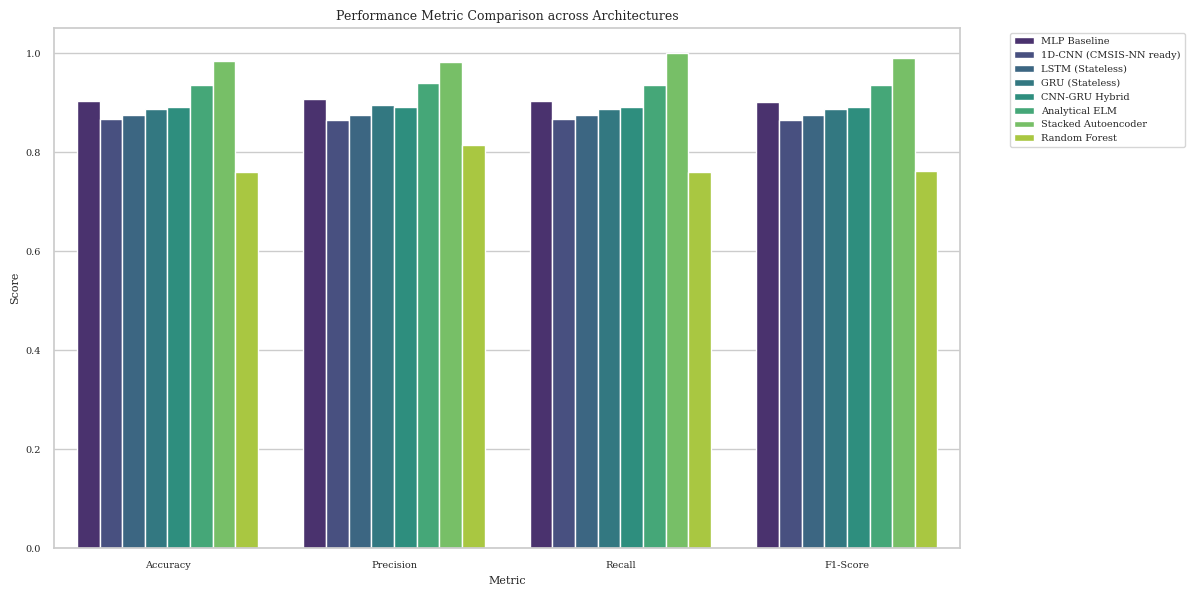

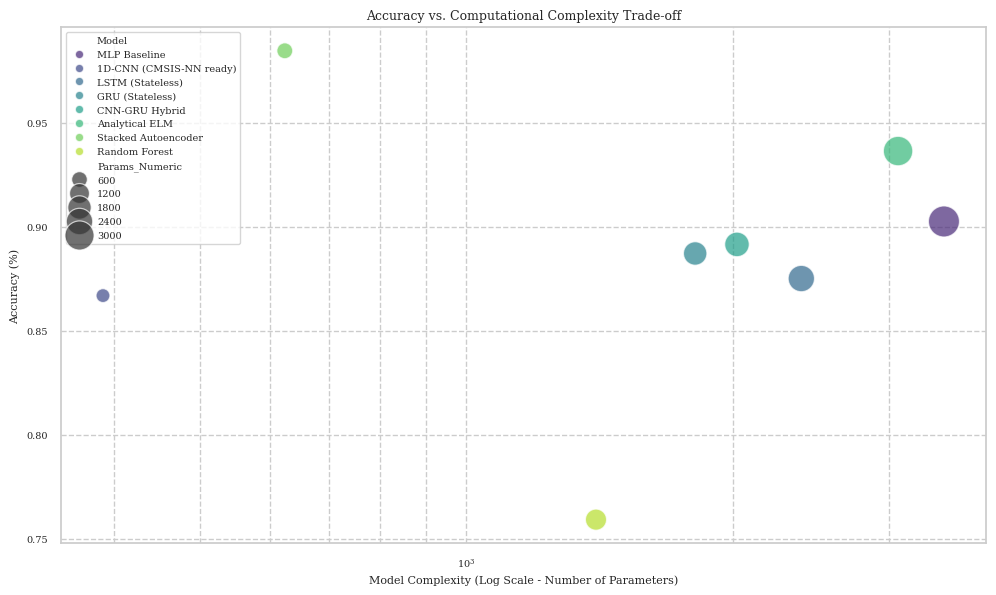

In [ ]:
# plotting results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_paper_plots(results_dict):
    """
    Generates publication-quality figures for model benchmarking.
    """
    # Convert results to DataFrame
    df = pd.DataFrame(results_dict).T
    df.index.name = 'Model'
    df.reset_index(inplace=True)

    # Set paper-grade aesthetics
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12
    })
    setup_ieee_style()
    # 1. Grouped Bar Chart for Performance Metrics
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    df_melted = df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')
    plt.ylim(0, 1.05) # Assume scores are 0-1
    plt.title('Performance Metric Comparison across Architectures')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('performance_comparison.pdf', dpi=300) # PDF is preferred for LaTeX/papers
    print("✅ Saved 'performance_comparison.pdf'")

    # 2. Complexity vs. Accuracy Plot (Bubble Plot)
    # This is highly valued in power system research to show trade-offs
    plt.figure(figsize=(10, 6))
    # Convert 'Parameters' string back to numeric if necessary
    df['Params_Numeric'] = df['Parameters'].replace(',', '', regex=True).astype(float)

    sns.scatterplot(data=df, x='Params_Numeric', y='Accuracy', size='Params_Numeric',
                    sizes=(100, 500), hue='Model', palette='viridis', alpha=0.7)

    plt.xscale('log') # Log scale is essential for parameter counts
    plt.xlabel('Model Complexity (Log Scale - Number of Parameters)')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy vs. Computational Complexity Trade-off')
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.savefig('complexity_tradeoff.pdf', dpi=300)
    print("✅ Saved 'complexity_tradeoff.pdf'")

# --- Integration ---
# After populating your results_dict in train_and_benchmark.py:
generate_paper_plots(results_dict)

##Plot for dataset

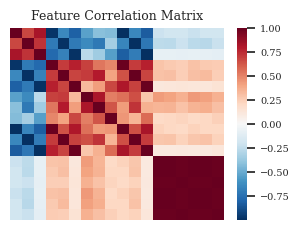

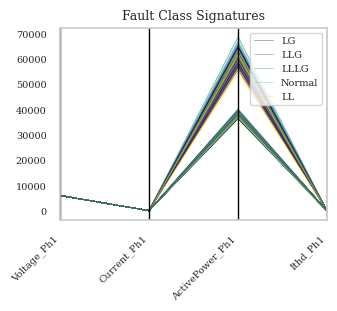

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

# IEEE A4 Column setup
plt.rcParams.update({"font.family": "serif", "font.size": 8, "figure.figsize": (3.45, 2.5)})

def plot_dataset_analysis(df):
    # 1. Correlation Heatmap
    plt.figure()
    setup_ieee_style()
    # Define mapping for professional labeling

    sns.heatmap(df.drop(columns=['FaultType']).corr(), cmap='RdBu_r', center=0, xticklabels=False, yticklabels=False)
    plt.title("Feature Correlation Matrix")
    plt.savefig('feat_corr.pdf', bbox_inches='tight')
    label_map = {
    'Voltage_Ph1': 'V1', 'Voltage_Ph2': 'V2', 'Voltage_Ph3': 'V3',
    'Current_Ph1': 'I1', 'Current_Ph2': 'I2', 'Current_Ph3': 'I3',
    'ActivePower_Ph1': 'P1', 'ActivePower_Ph2': 'P2', 'ActivePower_Ph3': 'P3',
    'ReactivePower_Ph1': 'Q1', 'ReactivePower_Ph2': 'Q2', 'ReactivePower_Ph3': 'Q3',
    'Vthd_Ph1': 'THDv1', 'Vthd_Ph2': 'THDv2', 'Vthd_Ph3': 'THDv3',
    'Ithd_Ph1': 'THDi1', 'Ithd_Ph2': 'THDi2', 'Ithd_Ph3': 'THDi3'
        }

    # Apply to dataframe before plotting
    df_renamed = df.rename(columns=label_map)

    # 2. Parallel Coordinates (Select subset of features for readability)
    # Visualizing 18 features is dense; suggest picking 6-8 representative ones
    plt.figure()
    subset = df[['Voltage_Ph1', 'Current_Ph1', 'ActivePower_Ph1', 'Ithd_Ph1', 'FaultType']].sample(500)
    parallel_coordinates(subset, 'FaultType', colormap='viridis', linewidth=0.5, alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.title("Fault Class Signatures")
    plt.savefig('parallel_coords.pdf', bbox_inches='tight')
plot_dataset_analysis(df)